# S pombe ecDNA analysis

Modification of img-explorer to process _S pombe_ image data, using both nuclear and cell segmentation

In [1]:
# Import necessary packages

import os, glob, re, logging
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from collections import defaultdict

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
# Define path names and data folders to process

# Define the location of the files to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # data directory
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory

experiment_list = ["08262025_Taka_pombe-live"]

In [3]:
# Do some housekeeping first

# Define the folder structure within each experiment
file_folders = {
    "image": "MIPs/MIPs_multichannel/", 
    "mask_n": "segmentation-masks/nuclei_masks/",
    "mask_c": "segmentation-masks/whole-cell_masks/"
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

### Read files

The chunks below: 
1. read in multi-channel MIPs ("images"), nuclear masks, cell masks and spot coordinates
2. match images and mask file indexes to make sure they're paired correctly
3. display the overlay of image, cell masks and nuclear masks for one image

In [4]:
# CHUNK 1 # 
# Load maximum intensity projection (MIP) files
# and segmentation masks for images in all experiments listed

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"image": [], "mask_n": [], "mask_c": []},
        "file_names": {"image": [], "mask_n": [], "mask_c": []},
        "base_names": {"image": [], "mask_n": [], "mask_c": []},
        "errors": []
    }

    # Read in the experimental groups reference file for each experiment
    exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['image'])} images, {len(data['file_names']['mask_n'])} nuclei masks and {len(data['file_names']['mask_c'])} cell masks.")
    
# Now for each experiment, all_images["image"] contains all the images (MIPs), 
# all_images["mask_n"] contains all the nuclei masks and 
# all_images["mask_c"] contains all the cell masks

2025-09-23 16:45:00,324 - INFO - 08262025_Taka_pombe-live: All images and masks processed successfully without errors.
2025-09-23 16:45:00,325 - INFO - 08262025_Taka_pombe-live: Processed 33 images, 33 nuclei masks and 33 cell masks.


In [5]:
# Optional: check dimensions of a given set of images, to verify they're correct

# Define function to check dimensions of images and masks
def img_sizr(image_types, file_indices, all_images):
    for f in file_indices:
        for image_type in image_types:
            try:
                image_shape = all_images[image_type][f].shape
                logging.info(f"File {f} ({image_type}): {image_shape}")
            except IndexError:
                logging.warning(f"File index {f} for {image_type} is out of range.")
            except KeyError:
                logging.error(f"Image type {image_type} does not exist.")

# Define the list of image types to check
image_types_to_check = ['image', 'mask_n', 'mask_c']  # Add 'mask_b' if you want to check background masks too

# And the list of file indices to check
test_files = [3, 4]

# Loop over each experiment in all_experiments_data
for experiment, data in all_experiments_data.items():
    logging.info(f"Running dimension check for experiment: {experiment}")
    img_sizr(image_types_to_check, test_files, data["all_images"])

2025-09-23 16:45:03,071 - INFO - Running dimension check for experiment: 08262025_Taka_pombe-live
2025-09-23 16:45:03,076 - INFO - File 3 (image): (3, 2048, 2048)
2025-09-23 16:45:03,079 - INFO - File 3 (mask_n): (2048, 2048)
2025-09-23 16:45:03,079 - INFO - File 3 (mask_c): (2048, 2048)
2025-09-23 16:45:03,080 - INFO - File 4 (image): (3, 2048, 2048)
2025-09-23 16:45:03,080 - INFO - File 4 (mask_n): (2048, 2048)
2025-09-23 16:45:03,081 - INFO - File 4 (mask_c): (2048, 2048)


In [6]:
# CHUNK 2 # 
# Load spots data, if required

# Define some functions for loading
def load_spot_files(parent_directory, experiment, spots_folder="spotiflow_results"):
    """
    Lazy-load spot CSVs for a single experiment.
    Returns a dict matching your previous structure.
    """
    exp_spots = {
        "spot_files": {"spots": []},
        "spot_file_names": {"spots": []},
        "spot_base_names": {"spots": []},
        "spot_channels": [],
        "spot_errors": []
    }

    spots_path = os.path.join(parent_directory, experiment, spots_folder)
    csv_files = sorted(glob.glob(os.path.join(spots_path, "*.csv")))
    if not csv_files:
        logging.info(f"{experiment}: no spot files found in {spots_path}")
        return exp_spots

    for file in csv_files:
        try:
            spots = pd.read_csv(file)  # adjust dtype/columns if needed
            file_name = os.path.basename(file)

            # Robust channel extraction: supports C1-, C02_, c10-, etc.
            m = re.match(r'^[Cc](\d+)[-_]', file_name)
            channel = int(m.group(1)) if m else None

            exp_spots["spot_files"]["spots"].append(spots)
            exp_spots["spot_file_names"]["spots"].append(file_name)
            exp_spots["spot_base_names"]["spots"].append(extract_base_name(file_name))
            exp_spots["spot_channels"].append(channel)

        except Exception as e:
            exp_spots["spot_errors"].append({"file": file, "error": str(e)})
            logging.error(f"Error reading {file} in {experiment}: {str(e)}")

    if exp_spots["spot_errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_spots['spot_errors'])} files.")
    else:
        logging.info(f"{experiment}: All spot files loaded successfully ({len(csv_files)}).")

    return exp_spots

def ensure_spots_loaded(all_experiments_data, parent_directory, experiment, **kwargs):
    """
    Load spots for one experiment only if not already loaded.
    Stores under all_experiments_data[experiment]['spots'].
    """
    exp_data = all_experiments_data[experiment]
    if "spots" not in exp_data:
        exp_data["spots"] = load_spot_files(parent_directory, experiment, **kwargs)
    return exp_data["spots"]

# Optional: convenience to get a legacy-style dict if some code still expects it
def spots_dict_view(all_experiments_data, experiment_list):
    return {
        exp: all_experiments_data[exp].get("spots", {
            "spot_files": {"spots": []},
            "spot_file_names": {"spots": []},
            "spot_base_names": {"spots": []},
            "spot_channels": [],
            "spot_errors": []
        })
        for exp in experiment_list
    }

In [7]:
# Load spots data
for exp in experiment_list:
    ensure_spots_loaded(all_experiments_data, parent_directory, exp, spots_folder = "spotiflow_results")

2025-09-23 12:12:30,867 - INFO - 08262025_Taka_pombe-live: All spot files loaded successfully (33).


In [14]:
# Optional: if need all_experiments_spots for older code, generate by running:
all_experiments_spots = spots_dict_view(all_experiments_data, experiment_list)

In [8]:
# CHUNK 3 #
# Match image indices to mask indices, to make sure they're paired correctly
# as they may not have been read in the same order

# Loop over each experiment in all_experiments_data to match image and mask indices
for experiment, data in all_experiments_data.items():
    logging.info(f"Matching image indices to mask indices for experiment: {experiment}")

    # Access the base names for images and masks in this experiment
    image_base_names = data['base_names']['image']
    nuc_base_names   = data['base_names']['mask_n']   # nuclear masks
    cell_base_names  = data['base_names']['mask_c']   # cell masks

    # Fast lookup: base_name -> index
    img_name_to_idx  = {bn: i for i, bn in enumerate(image_base_names)}
    nuc_name_to_idx  = {bn: i for i, bn in enumerate(nuc_base_names)}
    cell_name_to_idx = {bn: i for i, bn in enumerate(cell_base_names)}

    matched_triples = []
    missing_nuc = 0
    missing_cell = 0
    
    # Match by iterating over images (primary driver)
    for img_idx, bn in enumerate(image_base_names):
        n_idx = nuc_name_to_idx.get(bn)
        c_idx = cell_name_to_idx.get(bn)

        if n_idx is None:
            missing_nuc += 1
            logging.warning(f"[{experiment}] No matching NUCLEAR mask for image base_name='{bn}'")

        if c_idx is None:
            missing_cell += 1
            logging.warning(f"[{experiment}] No matching CELL mask for image base_name='{bn}'")

        # Only keep fully matched triplets
        if (n_idx is not None) and (c_idx is not None):
            matched_triples.append((img_idx, n_idx, c_idx))

    # Masks that don't have a corresponding image (useful for sanity checks)
    nuc_without_image  = sorted(set(nuc_name_to_idx.keys())  - set(img_name_to_idx.keys()))
    cell_without_image = sorted(set(cell_name_to_idx.keys()) - set(img_name_to_idx.keys()))

    # Log summary
    logging.info(
        f"{experiment}: Matched {len(matched_triples)} (image, nuc, cell) triplets. "
        f"Missing nuclear for {missing_nuc} images; missing cell for {missing_cell} images."
    )
    if nuc_without_image:
        logging.info(f"[{experiment}] Nuclear masks with no image match: {len(nuc_without_image)}")
    if cell_without_image:
        logging.info(f"[{experiment}] Cell masks with no image match: {len(cell_without_image)}")

    # Store results for downstream analysis
    data["matched_indices"] = matched_triples
    data["unmatched"] = {
        "images_missing_nuclear": missing_nuc,
        "images_missing_cell": missing_cell,
        "nuc_masks_without_image": nuc_without_image,
        "cell_masks_without_image": cell_without_image,
    }

# Now, data["matched_indices"] contains (img_idx, nuc_mask_idx, cell_mask_idx) triplets per experiment

2025-09-23 16:45:21,035 - INFO - Matching image indices to mask indices for experiment: 08262025_Taka_pombe-live
2025-09-23 16:45:21,039 - INFO - 08262025_Taka_pombe-live: Matched 33 (image, nuc, cell) triplets. Missing nuclear for 0 images; missing cell for 0 images.


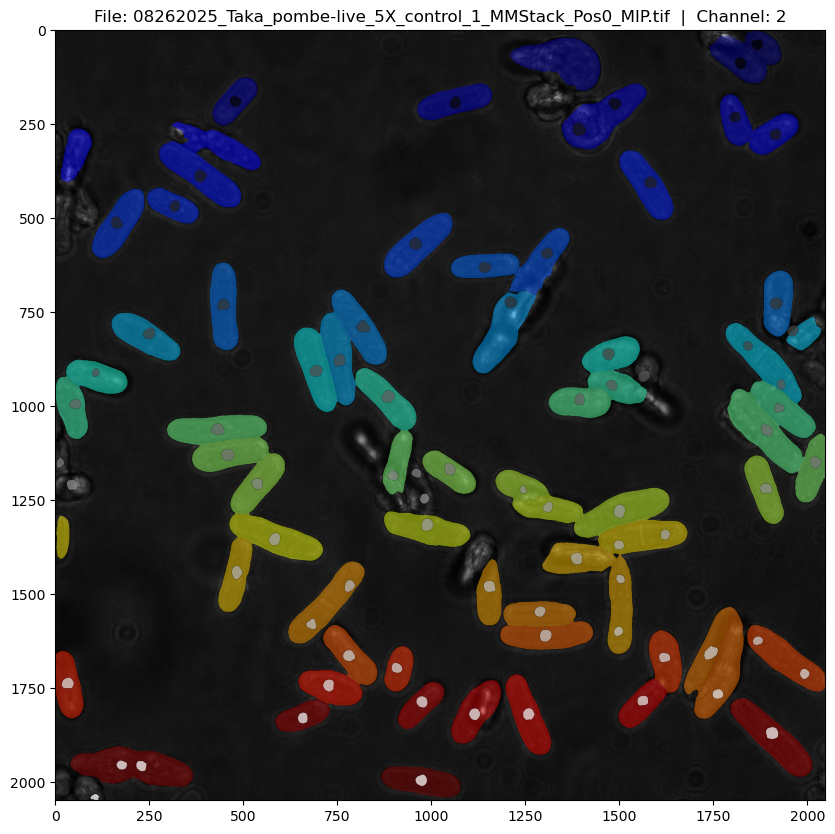

In [9]:
# Overlay the corresponding masks on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the image to check
# and the channel to plot — remember C-1 for ImageJ is channel 0 for Python!
e_index = 0
image_index = 21

# Replace with the desired index
c = 2 # remember the channel order in these images

# Access the specific experiment's data
experiment_key = experiment_list[e_index]
experiment_data = all_experiments_data[experiment_key]

# Find the corresponding mask index for the specified image
# and define the image and mask pair
matched_indices = experiment_data["matched_indices"]

try:
    img_idx, nuc_idx, cell_idx = next(trip for trip in matched_indices if trip[0] == image_index)
except StopIteration:
    raise ValueError(f"No matched masks found for image_index={image_index} in experiment '{experiment_key}'")

# Define image and both masks
my_image   = experiment_data['all_images']['image'][image_index]
image_file = experiment_data['file_names']['image'][image_index]
my_mask_n  = experiment_data['all_images']['mask_n'][nuc_idx]
my_mask_c  = experiment_data['all_images']['mask_c'][cell_idx]

# Select the channel to display
channel_image = my_image[c, ...]

# Sanity checks on shapes
if channel_image.shape != my_mask_n.shape or channel_image.shape != my_mask_c.shape:
    print("Warning: The image and one or more masks have different sizes. Please check your data.")
else:
    # Mask background (0) so only labeled regions are drawn
    cell_overlay = np.ma.masked_where(my_mask_c == 0, my_mask_c)
    nuc_overlay  = np.ma.masked_where(my_mask_n == 0, my_mask_n)

    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')              # base image in grayscale
    plt.imshow(cell_overlay, cmap='jet', alpha=0.5)    # cell mask in jet
    plt.imshow(nuc_overlay,  cmap='gray', alpha=0.75)    # nuclear mask in grayscale on top
    plt.title(f'File: {image_file}  |  Channel: {c}')
    # plt.axis('off')
    plt.show()

### Match cells and nuclei

The next few cells:
1. match nuclei masks to cell masks so that each nucleus is assigned to a cell body. It does this based on pixel overlap. The cell ID (cell_ID) will be our reference, since one cell can have multiple nuclei. Values of cell_ID == 0 are considered background.
2. Nuclei with no matched cell (nuclear ID > 0 AND cell_ID == 0) and cells with no nucleus (cell_ID > 0 AND nuc_ID == 0) will be labelled as "unassigned" and "empty" and ultimately thrown out
3. Create a summary table of nuclei counts per cell and a plot to inspect the distribution of number of nuclei per cell

In [10]:
# Create a function that matches nuclear masks to cell masks using pixel overlap

from collections import defaultdict

def assign_nuclei_to_cells(
    nuc_mask: np.ndarray,
    cell_mask: np.ndarray,
    min_overlap_px: int = 0,
    min_overlap_frac: float | None = None
):
    """
    Assign each nucleus (nuc_ID) to the cell (cell_ID) it overlaps the most,
    enforcing a minimum overlap requirement.

    Parameters
    ----------
    nuc_mask : 2D ndarray of int
        Labeled nuclear mask (0 = background, 1..N = nuclei labels).
    cell_mask : 2D ndarray of int
        Labeled cell mask (0 = background, 1..M = cell labels).
    min_overlap_px : int, default=0
        Minimum number of overlapping pixels required to assign a nucleus to a cell.
    min_overlap_frac : float in (0,1], optional
        Minimum fraction of the nucleus area that must overlap a cell to assign.
        If provided alongside min_overlap_px, both conditions must be met.

    Returns
    -------
    dict:
        {
          "nuc_to_cell": {nuc_ID -> cell_ID_or_0},
          "cell_to_nucs": {cell_ID -> [nuc_ID, ...]},
          "unassigned_nuclei": [nuc_ID, ...],
          "empty_cells": [cell_ID, ...],
          "nuc_as_cellID_mask": 2D ndarray (each nucleus pixel = its assigned cell_ID, else 0),
          "n_nuclei": int,
          "n_cells": int,
        }
    """
    if nuc_mask.shape != cell_mask.shape:
        raise ValueError("nuc_mask and cell_mask must have same shape")

    nuc_labels = np.unique(nuc_mask)
    nuc_labels = nuc_labels[nuc_labels != 0]
    cell_labels = np.unique(cell_mask)
    cell_labels = cell_labels[cell_labels != 0]

    nuc_to_cell = {}
    cell_to_nucs = defaultdict(list)
    nuc_as_cellID_mask = np.zeros_like(nuc_mask, dtype=cell_mask.dtype)

    for n_id in nuc_labels:
        n_region = (nuc_mask == n_id)
        n_area = int(n_region.sum())
        overlapped_cells = cell_mask[n_region]
        overlapped_cells = overlapped_cells[overlapped_cells != 0]

        if overlapped_cells.size == 0:
            nuc_to_cell[n_id] = 0
            continue

        unique_cells, counts = np.unique(overlapped_cells, return_counts=True)
        best_idx = int(np.argmax(counts))
        best_cell = int(unique_cells[best_idx])
        best_overlap_px = int(counts[best_idx])

        # Apply minimum-overlap criteria
        passes_px = (best_overlap_px >= min_overlap_px)
        passes_frac = True
        if (min_overlap_frac is not None) and (min_overlap_frac > 0):
            # fraction relative to nucleus area
            passes_frac = (best_overlap_px >= min_overlap_frac * n_area)

        if passes_px and passes_frac:
            nuc_to_cell[n_id] = best_cell
            nuc_as_cellID_mask[n_region] = best_cell
        else:
            nuc_to_cell[n_id] = 0  # unassigned

    # Build reverse mapping and diagnostics
    for n_id, c_id in nuc_to_cell.items():
        if c_id != 0:
            cell_to_nucs[c_id].append(int(n_id))

    empty_cells = [int(c) for c in cell_labels if len(cell_to_nucs.get(int(c), [])) == 0]
    unassigned_nuclei = [int(n) for n, c in nuc_to_cell.items() if c == 0]

    return {
        "nuc_to_cell": nuc_to_cell,
        "cell_to_nucs": dict(cell_to_nucs),
        "unassigned_nuclei": unassigned_nuclei,
        "empty_cells": empty_cells,
        "nuc_as_cellID_mask": nuc_as_cellID_mask,
        "n_nuclei": int(len(nuc_labels)),
        "n_cells": int(len(cell_labels)),
    }

In [11]:
# CHUNK 4 # 
# Map each nucleus to its corresponding cell mask 

# Set your thresholds here
MIN_OVERLAP_PX = 10           # e.g., require ≥10 px overlap
MIN_OVERLAP_FRAC = 0.05       # e.g., require ≥5% of nucleus area to be inside a cell (set None to disable)

for experiment in experiment_list:
    exp_data = all_experiments_data[experiment]
    matched_triples = exp_data["matched_indices"]  # list of (img_idx, nuc_idx, cell_idx)

    exp_results = []  # one entry per matched triple

    total_nuclei = 0
    total_cells = 0
    total_unassigned_nuclei = 0
    total_empty_cells = 0

    for (img_idx, nuc_idx, cell_idx) in matched_triples:
        nuc_mask = exp_data["all_images"]["mask_n"][nuc_idx]
        cell_mask = exp_data["all_images"]["mask_c"][cell_idx]

        if nuc_mask.ndim != 2 or cell_mask.ndim != 2:
            raise ValueError(f"Masks must be 2D label images; got shapes {nuc_mask.shape} and {cell_mask.shape}")

        result = assign_nuclei_to_cells(
            nuc_mask,
            cell_mask,
            min_overlap_px=MIN_OVERLAP_PX,
            min_overlap_frac=MIN_OVERLAP_FRAC
        )

        exp_results.append({
            "image_index": img_idx,
            "nuc_index": nuc_idx,
            "cell_index": cell_idx,
            **result,
        })

        total_nuclei += result["n_nuclei"]
        total_cells += result["n_cells"]
        total_unassigned_nuclei += len(result["unassigned_nuclei"])
        total_empty_cells += len(result["empty_cells"])

    # Store per-experiment results
    exp_data["nuc_cell_assignments"] = exp_results

    # Single compact summary per experiment
    logging.info(
        f"[{experiment}] Summary: nuclei={total_nuclei}, cells={total_cells}, "
        f"unassigned_nuclei={total_unassigned_nuclei}, empty_cells={total_empty_cells} "
        f"(min_overlap_px={MIN_OVERLAP_PX}, min_overlap_frac={MIN_OVERLAP_FRAC})"
    )

2025-09-23 16:45:42,037 - INFO - [08262025_Taka_pombe-live] Summary: nuclei=3142, cells=2468, unassigned_nuclei=620, empty_cells=273 (min_overlap_px=10, min_overlap_frac=0.05)


In [12]:
# Write a function to turn the mapping into a data frame

def map_to_df(exp_results, experiment_name, exp_data):
    """
    Convert nucleus→cell assignment results for one experiment into a tidy DataFrame.
    Includes base_name for each image.
    
    exp_results = list of dicts (from exp_data["nuc_cell_assignments"])
    experiment_name = str
    exp_data = the experiment_data dict (to look up base_names)
    """
    rows = []
    for res in exp_results:
        img_idx = res["image_index"]
        base_name = exp_data["base_names"]["image"][img_idx]  # <-- lookup base_name

        nuc_to_cell = res["nuc_to_cell"]
        for nuc_id, cell_id in nuc_to_cell.items():
            rows.append({
                "experiment": experiment_name,
                "image_index": img_idx,
                "base_name": base_name, 
                "nuc_ID": int(nuc_id),
                "cell_ID": int(cell_id) if cell_id != 0 else None,  # None = unassigned
                "assigned": (cell_id != 0),
            })
    return pd.DataFrame(rows)

In [13]:
# Convert nucleus -> cell mapping into a data frame

cellnuc_pairs = []

for experiment in experiment_list:
    exp_data = all_experiments_data[experiment]
    exp_results = exp_data["nuc_cell_assignments"]
    df_exp = map_to_df(exp_results, experiment, exp_data)
    cellnuc_pairs.append(df_exp)

cellnuc_pairs = pd.concat(cellnuc_pairs, ignore_index=True)

In [14]:
# Inspect, if needed
print(cellnuc_pairs.head())

                 experiment  image_index  \
0  08262025_Taka_pombe-live            0   
1  08262025_Taka_pombe-live            0   
2  08262025_Taka_pombe-live            0   
3  08262025_Taka_pombe-live            0   
4  08262025_Taka_pombe-live            0   

                                           base_name  nuc_ID  cell_ID  \
0  08262025_Taka_pombe-live_5X_control_1_MMStack_...       1      2.0   
1  08262025_Taka_pombe-live_5X_control_1_MMStack_...       2      3.0   
2  08262025_Taka_pombe-live_5X_control_1_MMStack_...       3      4.0   
3  08262025_Taka_pombe-live_5X_control_1_MMStack_...       4      1.0   
4  08262025_Taka_pombe-live_5X_control_1_MMStack_...       5      6.0   

   assigned  
0      True  
1      True  
2      True  
3      True  
4      True  


In [15]:
# Generate a data frame containing only true nucleus-cell pairs (those cells that contain a nucleus)
# (assigned + non-null cell_ID)

real_pairs_df = (
    cellnuc_pairs
      .loc[cellnuc_pairs["assigned"] & cellnuc_pairs["cell_ID"].notna(),
           ["experiment", "base_name", "image_index", "nuc_ID", "cell_ID", "assigned"]]
      .copy()
)

# Ensure integer dtypes for IDs
real_pairs_df["nuc_ID"]  = real_pairs_df["nuc_ID"].astype(int)
real_pairs_df["cell_ID"] = real_pairs_df["cell_ID"].astype(int)

# Optional: sort for easier inspection
real_pairs_df = real_pairs_df.sort_values(
    ["experiment", "base_name", "image_index", "cell_ID", "nuc_ID"]
).reset_index(drop=True)

In [16]:
# Inspect
print("real_pairs_df preview:")
print(real_pairs_df.head())

real_pairs_df preview:
                 experiment  \
0  08262025_Taka_pombe-live   
1  08262025_Taka_pombe-live   
2  08262025_Taka_pombe-live   
3  08262025_Taka_pombe-live   
4  08262025_Taka_pombe-live   

                                           base_name  image_index  nuc_ID  \
0  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       1   
1  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       3   
2  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       5   
3  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27      10   
4  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       7   

   cell_ID  assigned  
0        1      True  
1        3      True  
2        4      True  
3        5      True  
4        6      True  


In [17]:
# Now count the number of nucleus per cell, should we want to classify or select based on this

nuclei_counts = (
    real_pairs_df
      .groupby(["experiment", "base_name", "image_index", "cell_ID"], as_index=False)
      .agg(n_nuclei=("nuc_ID", "count"))
      .sort_values(["experiment", "base_name", "image_index", "cell_ID"])
      .reset_index(drop=True)
)

In [18]:
# Inspect the data frame
print("\nnuclei_counts preview:")
print(nuclei_counts.head())


nuclei_counts preview:
                 experiment  \
0  08262025_Taka_pombe-live   
1  08262025_Taka_pombe-live   
2  08262025_Taka_pombe-live   
3  08262025_Taka_pombe-live   
4  08262025_Taka_pombe-live   

                                           base_name  image_index  cell_ID  \
0  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27        1   
1  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27        3   
2  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27        4   
3  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27        5   
4  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27        6   

   n_nuclei  
0         1  
1         1  
2         1  
3         1  
4         1  


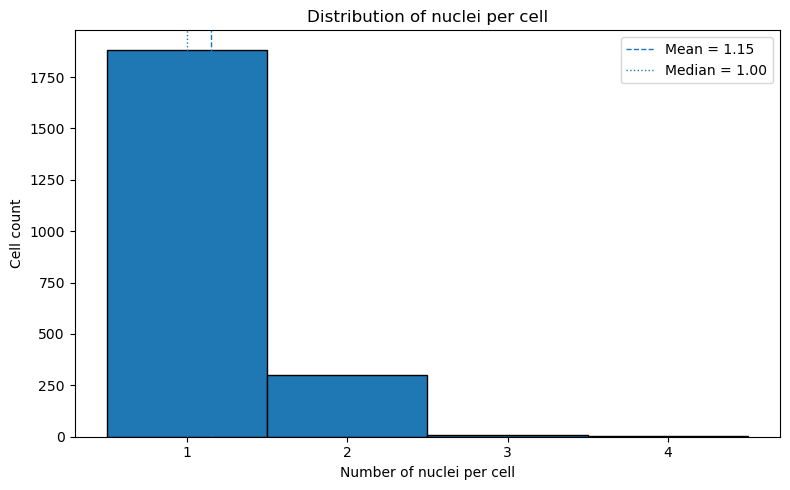

In [19]:
# Optional — plot a histogram showing the distribution of the number of nuclei in match_summary_df

# Ensure integer dtype
nuclei_counts["n_nuclei"] = nuclei_counts["n_nuclei"].astype(int)

if nuclei_counts.empty:
    print("nuclei_counts is empty; nothing to plot.")
else:
    vals = nuclei_counts["n_nuclei"].to_numpy()
    min_v, max_v = int(vals.min()), int(vals.max())
    # Integer-centered bins: [..., 0.5, 1.5, 2.5, ...]
    bins = np.arange(min_v - 0.5, max_v + 1.5, 1)

    plt.figure(figsize=(8, 5))
    plt.hist(vals, bins=bins, edgecolor="black")
    plt.xticks(range(min_v, max_v + 1))  # integer ticks
    plt.xlabel("Number of nuclei per cell")
    plt.ylabel("Cell count")
    plt.title("Distribution of nuclei per cell")

    # Mean & median reference lines
    mean_v = vals.mean()
    med_v = np.median(vals)
    plt.axvline(mean_v, linestyle="--", linewidth=1, label=f"Mean = {mean_v:.2f}")
    plt.axvline(med_v, linestyle=":",  linewidth=1, label=f"Median = {med_v:.2f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Spot assignment

The chunks below:
1. Create a few functions to assign spots to nuclei and cells based on their coordinates
2. Assign the spots found on each image to the nucleus or cytoplasm of each cell — it can expand the nuclear mask to account for spots found on the edges of the nucleus, which we found to be quite common and to affect the classification. No need to expand the cell masks, since there are few spots in the cytoplasm and they don't seem to accumulate on the periphery
3. Calculate a summary table of spots per cell (in nucleus vs cytoplasm)
4. Generate a plot showing number of spots in each compartment, in each experimental group

In [20]:
# CHUNK 5.1 #
# Assign spots to each cell and nucleus — i.e., annotate each spot with a cell_ID and nuc_ID
# Before assigning spots to nuclei, we will also dilate each nucleus by a factor of N pixels (0 by default)

from skimage.segmentation import expand_labels

# Define necessary functions

# This is a (perhaps a bit unnecessary) detector of the X and Y coordinates, 
# should they not be specified
def detect_xy_columns(df, prefer=("x","y")):
    candidates = [prefer, ("X","Y"), ("x_pix","y_pix"), ("x_px","y_px"), ("xp","yp"), ("x0","y0"), ("x1","y1")]
    cols = set(df.columns)
    for xk, yk in candidates:
        if xk in cols and yk in cols:
            return xk, yk
    # fallback: first two numeric columns
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) >= 2:
        return num_cols[0], num_cols[1]
    raise ValueError("Could not determine x/y columns in spots DataFrame")


# This is the function that will actually annotate the spots
def annotate_spots(
    spots_df,
    nuc_mask,
    cell_mask,
    x_col=None,
    y_col=None,
    require_nucleus: bool = False,
):
    """
    Return ONLY spots that fall inside a cell (cell_ID > 0).
    Adds just 'cell_ID' and 'nuc_ID' (nullable Int64). No extra flags.

    If require_nucleus=True, also require nuc_ID > 0. However, nuc_ID values == 0 could be either 
    in the cytoplasm (cell_ID > 0) or in the real background (cell_ID == 0)
    """
    out = spots_df.copy()
    if x_col is None or y_col is None:
        x_col, y_col = detect_xy_columns(out)
    out = out.loc[out[x_col].notna() & out[y_col].notna()].copy()

    if out.empty:
        return out.assign(
            cell_ID = pd.Series(dtype="Int64"),
            nuc_ID = pd.Series(dtype="Int64"),
        )

    xs = np.rint(out[x_col].to_numpy()).astype(int)
    ys = np.rint(out[y_col].to_numpy()).astype(int)

    h, w = cell_mask.shape
    xs = np.clip(xs, 0, w - 1)
    ys = np.clip(ys, 0, h - 1)

    cell_ids = cell_mask[ys, xs].astype(int)
    nuc_ids  = nuc_mask[ys, xs].astype(int)

    keep = (cell_ids > 0)
    if require_nucleus:
        keep &= (nuc_ids > 0)

    if not np.any(keep):
        # return empty with columns
        return out.iloc[0:0].assign(
            cell_ID=pd.Series(dtype="Int64"),
            nuc_ID=pd.Series(dtype="Int64"),
        )

    idx = out.index[keep]
    out = out.loc[keep].copy()
    out["cell_ID"] = pd.Series(cell_ids[keep], index=idx, dtype="Int64")
    out["nuc_ID"]  = pd.Series(nuc_ids[keep],  index=idx, dtype="Int64")
    return out

# Lastly, this function does the heavy lifting for multiple experiments
def annotate_spots_for_experiment(
    exp_data,
    channels=None, # If you want to annotate spots for a specific channel, set to [2] or [1, 2, 4], whatever may be the case
    x_col=None,
    y_col=None,
    require_nucleus: bool = False,
    include_spot_file: bool = False,      
    verify_filename_match: bool = True,
    nuc_expand_px: int = 0,  
):
    """
    For one experiment:
      - uses exp_data["matched_indices"] (list of (img_idx, nuc_idx, cell_idx))
      - finds spot CSVs matching each image's base_name (and optionally channel filter)
      - expands nuclear masks by 'nuc_expand_px' pixels before sampling
      - annotates each spot row with cell_ID / nuc_ID, except those in the background region (ROI == 0)
      - returns a tidy DataFrame (and stores it under exp_data['spots']['annotated_spots_df'])

    Parameters
    ----------
    exp_data : dict
        Your per-experiment dict in all_experiments_data[experiment]
        Must contain:
          - 'matched_indices': list of (img_idx, nuc_idx, cell_idx)
          - 'base_names'['image']: list of base names for images
          - 'all_images'['mask_n'], ['mask_c']: lists of 2D label arrays
          - 'spots': structure with lists 'spot_files'['spots'], 'spot_file_names'['spots'],
                     'spot_base_names'['spots'], 'spot_channels'
    channels : list[int] | None
        If provided, only annotate spots from these channels.
    x_col, y_col : str | None
        Coordinate columns. If None, will auto-detect via detect_xy_columns.

    Returns
    -------
    spots_annot_df : DataFrame
        Columns include original spot CSV columns + metadata:
        ['experiment','base_name','image_index','channel','spot_file','cell_ID','nuc_ID']
    """
    def index_spot_files(exp_data):
        base_names = exp_data["spots"]["spot_base_names"]["spots"]
        channels   = exp_data["spots"]["spot_channels"]
        idx_map = defaultdict(list)
        for i, (bn, ch) in enumerate(zip(base_names, channels)):
            idx_map[(bn, ch)].append(i)
        return idx_map
    
    if "spots" not in exp_data or not exp_data["spots"]["spot_files"]["spots"]:
        df = pd.DataFrame()
        exp_data.setdefault("spots", {})["annotated_spots_df"] = df
        return df

    matched_triples = exp_data["matched_indices"]            # (img_idx, nuc_idx, cell_idx)
    img_base_names  = exp_data["base_names"]["image"]
    idx_map         = index_spot_files(exp_data)

    frames = []
    for (img_idx, nuc_idx, cell_idx) in matched_triples:
        base_name = img_base_names[img_idx]
        nuc_mask  = exp_data["all_images"]["mask_n"][nuc_idx]
        cell_mask = exp_data["all_images"]["mask_c"][cell_idx]

        # Expand nuclear labels once per image, reuse for all spot files/channels
        nuc_mask_eff = expand_labels(nuc_mask, distance = nuc_expand_px) if nuc_expand_px and nuc_expand_px > 0 else nuc_mask

        available_ch = sorted({ch for (bn, ch) in idx_map if bn == base_name})
        to_do = [ch for ch in available_ch if (channels is None or ch in channels)]

        for ch in to_do:
            for spot_i in idx_map.get((base_name, ch), []):
                df_raw = exp_data["spots"]["spot_files"]["spots"][spot_i]
                fname  = exp_data["spots"]["spot_file_names"]["spots"][spot_i]
                spot_bn  = exp_data["spots"]["spot_base_names"]["spots"][spot_i]

                if verify_filename_match and (spot_bn != base_name):
                    # Shouldn't happen because of idx_map, but good to guard.
                    logging.warning(f"Base-name mismatch: image='{base_name}' vs spots='{spot_bn}' in file {fname}")
                    continue

                df_ann = annotate_spots(
                    df_raw, nuc_mask_eff, cell_mask, 
                    x_col = x_col, y_col = y_col, 
                    require_nucleus = require_nucleus
                )
                if df_ann.empty:
                    continue

                meta = dict(base_name=base_name, image_index=img_idx, channel=ch)
                if include_spot_file:
                    meta["spot_file"] = fname

                df_ann = df_ann.assign(**meta)
                for col in ("cell_ID","nuc_ID"):
                    if col in df_ann.columns:
                        df_ann[col] = df_ann[col].astype("Int64")
                frames.append(df_ann)

    df_valid = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    exp_data["spots"]["annotated_spots_df"] = df_valid
    return df_valid

In [21]:
# CHUNK 5.2 # 
# Do the actual spot annotation and generate the data frame
# Dilating the nuclei is optional, but will help correctly assign spots on the perifery of the nucleus
# Define dilation factor (in pixels) below

npx = 15

# I tested pixel values from 0 to 25 and saw an increase in nuclear spots 
# from ~20% with no dilation, to a plateau at ~30% after 10-15px
# Below there is code to count and plot the values if we want to re-test

# Create an empty dictionary to store results
all_spots_annot = []

for experiment in experiment_list:
    exp_data = all_experiments_data[experiment]
    # lazy-load spot CSVs if not already loaded
    ensure_spots_loaded(all_experiments_data, parent_directory, experiment, spots_folder = "spotiflow_results")

    # Keep only spots inside cells; allow in- or out-of-nucleus (set True to require nucleus too)
    df_valid = annotate_spots_for_experiment(
        exp_data,
        channels=[1],
        x_col=None,
        y_col=None,
        nuc_expand_px=npx,
        require_nucleus=False  # <- set True if you want MUST be in a nucleus as well
    )
    if not df_valid.empty:
        all_spots_annot.append(df_valid.assign(experiment=experiment))

all_spots_annot = pd.concat(all_spots_annot, ignore_index=True) if all_spots_annot else pd.DataFrame()

2025-09-23 16:46:11,215 - INFO - 08262025_Taka_pombe-live: All spot files loaded successfully (33).


In [22]:
print("Annotated spots shape:", all_spots_annot.shape)
print(all_spots_annot.head(10))

Annotated spots shape: (1346, 10)
           y          x  intensity  probability  cell_ID  nuc_ID  \
0  1528.9034   693.8904     318.33        0.415       65       0   
1  1449.0000  1422.0000     772.00        0.374       57      61   
2  1447.9109  1424.7778     707.93        0.510       57      61   
3  1170.0816  1652.6187     382.59        0.477       46       0   
4   269.8575  1740.6866    1777.69        0.720       20      18   
5   168.1957  1805.1462     567.72        0.538       16      13   
6  1858.0000    98.0000     495.00        0.423       75      93   
7  1856.0000    96.0000     493.00        0.443       75      93   
8  1841.1593   100.0180     703.50        0.516       75      93   
9  1829.1451    75.3583     576.04        0.563       75       0   

                                           base_name  image_index  channel  \
0  08262025_Taka_pombe-live_5X_control_1_MMStack_...            0        1   
1  08262025_Taka_pombe-live_5X_control_1_MMStack_...         

In [23]:
# Sanity check to confirm there are no spots with <NA> as cell_ID or nuc_ID
assert not all_spots_annot["cell_ID"].isna().any(), "NA cell_ID found"
assert not all_spots_annot["nuc_ID"].isna().any(),  "NA nuc_ID found"
assert (all_spots_annot["cell_ID"] > 0).all()
# nuc_ID may be 0 (cyto) or >0 (nuclear)

In [90]:
# Reset the accumulator so a new run starts clean
dilation_results = []

In [87]:
# Run a simple calculator to count the number of nuclear, cytoplasmic spots, and spots outside cells
# This will let us evaluate the changes caused by changing the nucleus dilation factor

# --- 0) set this to whatever you used in the last run ---
current_expand = npx  # e.g., 2, 5, 10

# --- 1) counts from the annotated, *inside-cell* spots ---
nuclear_n = int((all_spots_annot["nuc_ID"] > 0).sum())
cyto_n    = int((all_spots_annot["nuc_ID"] == 0).sum())

# --- 2) total spots across the same scope (all raw CSV rows for matched base_names/channels) ---
#     This gives us background = total - (nuclear + cyto)
total_spots = 0
channels_filter = None  # must match the 'channels=' argument you passed to the annotator

for exp in experiment_list:
    exp_data = all_experiments_data[exp]
    # make sure spots were loaded for every experiment used
    ensure_spots_loaded(all_experiments_data, parent_directory, exp, spots_folder="spotiflow_results")

    matched_triples = exp_data["matched_indices"]  # (img_idx, nuc_idx, cell_idx)
    img_base_names  = exp_data["base_names"]["image"]
    base_names_used = {img_base_names[img_idx] for (img_idx, _, _) in matched_triples}

    # iterate over spot files and sum rows for those base_names (respecting channel filter)
    spot_bns  = exp_data["spots"]["spot_base_names"]["spots"]
    spot_chs  = exp_data["spots"]["spot_channels"]
    spot_dfs  = exp_data["spots"]["spot_files"]["spots"]

    for i, (bn, ch) in enumerate(zip(spot_bns, spot_chs)):
        if (bn in base_names_used) and (channels_filter is None or ch in channels_filter):
            total_spots += len(spot_dfs[i])

background_n = int(total_spots - (nuclear_n + cyto_n))
if total_spots == 0:
    print("No spots found in this run; skipping summary.")
else:
    nuclear_frac   = nuclear_n   / total_spots
    cyto_frac      = cyto_n      / total_spots
    background_frac= background_n/ total_spots

    # --- 3) stash one row per category so you can append across runs ---
    # create the accumulator once (outside your runs) as: dilation_results = []
    try:
        dilation_results
    except NameError:
        dilation_results = []

    dilation_results += [
        {"nuc_expand_px": current_expand, "region": "nuclear",   "count": nuclear_n,   "fraction": nuclear_frac},
        {"nuc_expand_px": current_expand, "region": "cytoplasm", "count": cyto_n,      "fraction": cyto_frac},
        {"nuc_expand_px": current_expand, "region": "background","count": background_n,"fraction": background_frac},
    ]


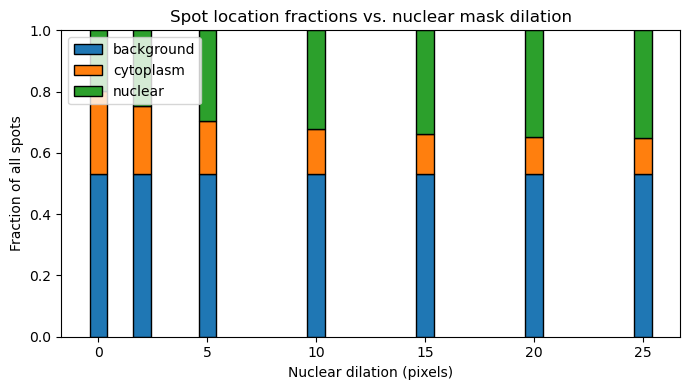

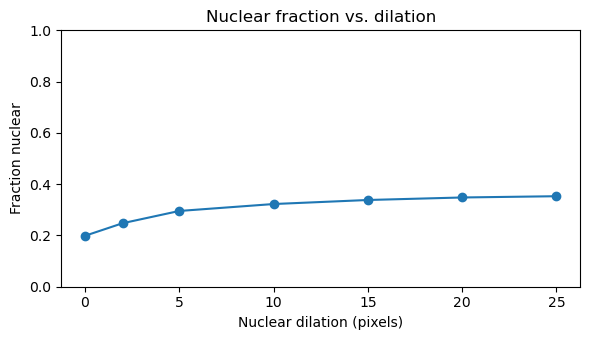

In [88]:
# And plot the results of the calculations above

dilation_df = pd.DataFrame(dilation_results)

# Ensure nice ordering
region_order = ["background", "cytoplasm", "nuclear"]
dilation_df["region"] = pd.Categorical(dilation_df["region"], categories=region_order, ordered=True)

# Pivot to wide for stacked bars
wide = (dilation_df
        .pivot(index="nuc_expand_px", columns="region", values="fraction")
        .fillna(0)
        .sort_index())

# --- Stacked bar (fractions sum to 1 per dilation) ---
fig, ax = plt.subplots(figsize=(7,4))
bottom = np.zeros(len(wide))
for r in region_order:
    ax.bar(wide.index, wide[r].to_numpy(), bottom=bottom, label=r, edgecolor="black")
    bottom += wide[r].to_numpy()
ax.set_xlabel("Nuclear dilation (pixels)")
ax.set_ylabel("Fraction of all spots")
ax.set_title("Spot location fractions vs. nuclear mask dilation")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# --- Optional: line plot for nuclear fraction only (easy trend read) ---
fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(wide.index, wide["nuclear"], marker="o")
ax.set_xlabel("Nuclear dilation (pixels)")
ax.set_ylabel("Fraction nuclear")
ax.set_title("Nuclear fraction vs. dilation")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

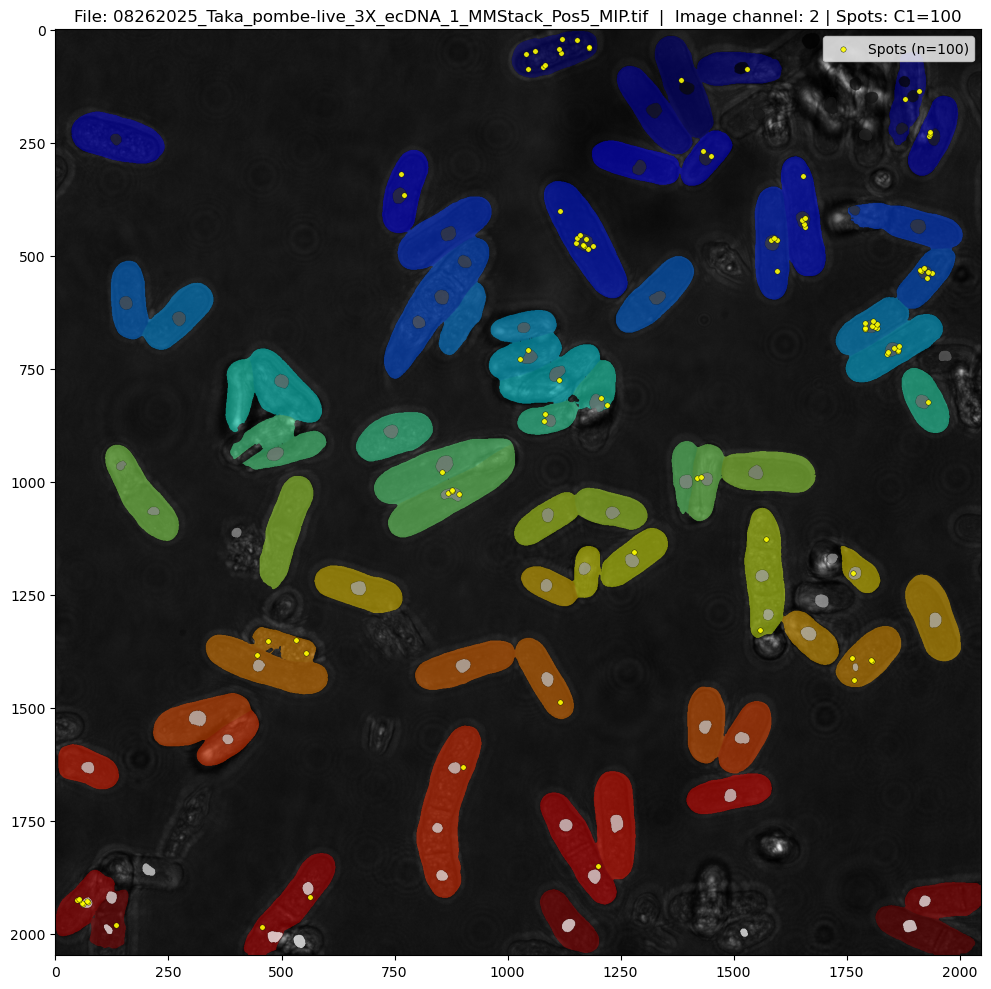

In [24]:
# Overlay the spots over the corresponding cell + nuclear masks on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the experiment and image to check
# and the channel to plot — remember C-1 for ImageJ is channel 0 for Python!
e_index = 0 # experiment index
image_index = 2 # image index
c = 2 # remember the channel order in these images
spot_channels_to_plot = None   # e.g., [2] to show only channel 2 spots; None = all channels
point_size = 15                # marker size for spots

# Access the specific experiment's data
experiment_key = experiment_list[e_index]
experiment_data = all_experiments_data[experiment_key]

spots_valid = experiment_data["spots"]["annotated_spots_df"]


# Find the corresponding mask index for the specified image
# and define the image and mask pair
matched_indices = experiment_data["matched_indices"]

try:
    img_idx, nuc_idx, cell_idx = next(trip for trip in matched_indices if trip[0] == image_index)
except StopIteration:
    raise ValueError(f"No matched masks found for image_index={image_index} in experiment '{experiment_key}'")

# Define image and both masks
my_image   = experiment_data['all_images']['image'][image_index]
image_file = experiment_data['file_names']['image'][image_index]
my_mask_n  = experiment_data['all_images']['mask_n'][nuc_idx]
my_mask_c  = experiment_data['all_images']['mask_c'][cell_idx]
channel_image = my_image[c, ...]

# Filter spots to this image (and optional channels)
if spots_valid is None or spots_valid.empty:
    spots_this = None
else:
    spots_this = spots_valid.loc[spots_valid["image_index"] == image_index]
    if spot_channels_to_plot is not None:
        spots_this = spots_this.loc[spots_this["channel"].isin(spot_channels_to_plot)]
    if spots_this.empty:
        spots_this = None

# Plot
if channel_image.shape != my_mask_n.shape or channel_image.shape != my_mask_c.shape:
    print("Warning: The image and one or more masks have different sizes. Please check your data.")
else:
    cell_overlay = np.ma.masked_where(my_mask_c == 0, my_mask_c)
    nuc_overlay  = np.ma.masked_where(my_mask_n == 0, my_mask_n)

    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')             # base image
    plt.imshow(cell_overlay, cmap='jet', alpha=0.5)    # cell mask (jet)
    plt.imshow(nuc_overlay,  cmap='gray', alpha=0.75)  # nuclear mask (gray on top)

    # Scatter spots as yellow dots (if any)
    if spots_this is not None:
        # Try to use canonical x/y; fall back to auto-detect if needed
        x_col = "x" if "x" in spots_this.columns else None
        y_col = "y" if "y" in spots_this.columns else None
        if x_col is None or y_col is None:
            x_col, y_col = detect_xy_columns(spots_this)

        plt.scatter(
            spots_this[x_col],
            spots_this[y_col],
            s=point_size,
            c='yellow',
            marker='o',
            edgecolors='black',
            linewidths=0.3,
            alpha=0.9,
            label=f"Spots (n={len(spots_this)})"
        )
        plt.legend(loc="upper right")

    # Compose a helpful title
    if spots_this is not None and "channel" in spots_this.columns:
        ch_counts = spots_this["channel"].value_counts().sort_index()
        ch_txt = ", ".join([f"C{int(k)}={int(v)}" for k, v in ch_counts.items()])
        title_extra = f" | Spots: {ch_txt}"
    else:
        title_extra = " | Spots: none"

    plt.title(f'File: {image_file}  |  Image channel: {c}{title_extra}')
    # plt.axis('off')
    plt.tight_layout()
    plt.show()

In [25]:
# CHUNK 6 # 
# Classify spots as nuclear or cytoplasmic based on their location within the cell

# Ensure nullable integer dtype is handled cleanly
if "nuc_ID" not in all_spots_annot.columns:
    raise KeyError("Expected column 'nuc_ID' not found in all_spots_annot")

all_spots_annot = all_spots_annot.assign(
    spot_loc = np.where(all_spots_annot["nuc_ID"].fillna(0).astype(int) > 0, "nuclear", "cyto")
)

# (Optional) use a categorical dtype to save memory / keep order
all_spots_annot["spot_loc"] = pd.Categorical(all_spots_annot["spot_loc"],
                                             categories = ["nuclear", "cyto"], ordered = True)

# Quick check (optional):
print(all_spots_annot["spot_loc"].value_counts())

spot_loc
nuclear    981
cyto       365
Name: count, dtype: int64


In [26]:
# Count nuclear and cytoplasmic spots for each cell-nucleus pair

# Keys for joining (adjust if you didn't include "experiment")
PAIR_KEYS = ["experiment", "base_name", "image_index", "cell_ID", "nuc_ID"]
CELL_KEYS = ["experiment", "base_name", "image_index", "cell_ID"]

# 1) Count nuclear spots per cell–nucleus pair (nuc_ID > 0)
nuclear_counts = (
    all_spots_annot
      .loc[all_spots_annot["nuc_ID"].fillna(0).astype(int) > 0, PAIR_KEYS]
      .value_counts()
      .reset_index(name="n_spots_nuclear")
)

# 2) Count cytoplasmic spots per cell (nuc_ID == 0)
cyto_counts = (
    all_spots_annot
      .loc[all_spots_annot["nuc_ID"].fillna(0).astype(int) == 0, CELL_KEYS]
      .value_counts()
      .reset_index(name="n_spots_cyto")
)

# 3) Start from the full set of cell–nucleus pairs and merge counts (keep zeros)
spot_pair_summary = (
    real_pairs_df
      .merge(nuclear_counts, on=PAIR_KEYS, how="left")
      .merge(cyto_counts, on=CELL_KEYS,  how="left")
      .fillna({"n_spots_nuclear": 0, "n_spots_cyto": 0})
      .assign(
          n_spots_nuclear=lambda d: d["n_spots_nuclear"].astype(int),
          n_spots_cyto   =lambda d: d["n_spots_cyto"].astype(int),
          n_spots_total  =lambda d: d["n_spots_nuclear"] + d["n_spots_cyto"]
      )
)

# Optional: sort for inspection
spot_pair_summary = spot_pair_summary.sort_values(
    ["experiment", "base_name", "image_index", "cell_ID", "nuc_ID"]
).reset_index(drop=True)

print(spot_pair_summary.head())

                 experiment  \
0  08262025_Taka_pombe-live   
1  08262025_Taka_pombe-live   
2  08262025_Taka_pombe-live   
3  08262025_Taka_pombe-live   
4  08262025_Taka_pombe-live   

                                           base_name  image_index  nuc_ID  \
0  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       1   
1  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       3   
2  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       5   
3  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27      10   
4  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       7   

   cell_ID  assigned  n_spots_nuclear  n_spots_cyto  n_spots_total  
0        1      True                0             0              0  
1        3      True                0             0              0  
2        4      True                0             0              0  
3        5      True                0             0              0  
4    

In [27]:
# Read in experimental group data for all experiments
frames = []
groups_filename = "experimental-groups.csv"

for exp in experiment_list:
    path = os.path.join(parent_directory, exp, groups_filename)
    if not os.path.exists(path):
        logging.warning(f"{exp}: '{groups_filename}' not found at {path}")
        continue

    try:
        df = pd.read_csv(path)
    except Exception as e:
        logging.error(f"{exp}: failed reading {path}: {e}")
        continue

    # --- ensure required columns ---
    # filename (or base_name as fallback)
    if "filename" not in df.columns:
        if "base_name" in df.columns:
            df = df.rename(columns={"base_name": "filename"})
        else:
            logging.error(f"{exp}: missing 'filename' (and no 'base_name' to infer). Skipping.")
            continue

    # group
    if "group" not in df.columns:
        logging.error(f"{exp}: missing 'group'. Skipping.")
        continue

    # experiment -> prefer column 'experiment_folder' if present; else use folder name
    if "experiment_folder" in df.columns:
        df = df.rename(columns={"experiment_folder": "experiment"})
    if "experiment" not in df.columns:
        df["experiment"] = exp
    else:
        df["experiment"] = (
            df["experiment"].fillna(exp).astype(str).str.strip().replace({"": exp})
        )

    # clean filename
    df["filename"] = df["filename"].astype(str).str.strip()

    # rename filename -> base_name for consistency
    df = df.rename(columns={"filename": "base_name"})

    # --- STANDARDIZE base_name to match your other tables: ".ome.tif" -> "_MIP" ---
    # If it already ends with _MIP, leave as is; otherwise replace a *trailing* ".ome.tif" (case-insensitive).
    mask_already_mip = df["base_name"].str.endswith("_MIP", na=False)
    df.loc[~mask_already_mip, "base_name"] = (
        df.loc[~mask_already_mip, "base_name"]
          .str.replace(r"\.ome\.tif$", "_MIP", regex=True, flags=re.IGNORECASE)
    )

    # (Optional) log how many rows were converted this pass
    n_converted = (~mask_already_mip & df["base_name"].str.endswith("_MIP", na=False)).sum()
    if n_converted:
        logging.info(f"{exp}: standardized {n_converted} base_name(s) to '_MIP' suffix")

    frames.append(df)

# --- combine all experiments ---
if frames:
    exp_groups = pd.concat(frames, ignore_index=True, sort=True)
    # enforce key dtypes
    exp_groups["experiment"] = exp_groups["experiment"].astype(str)
    exp_groups["base_name"]  = exp_groups["base_name"].astype(str)
    # drop exact duplicates
    exp_groups = exp_groups.drop_duplicates()

    # optional: put key columns first
    key_cols = ["experiment", "base_name", "group"]
    other_cols = [c for c in exp_groups.columns if c not in key_cols]
    exp_groups = exp_groups[key_cols + other_cols]
else:
    logging.warning("No experimental-groups.csv files were loaded.")
    exp_groups = pd.DataFrame(columns=["experiment", "base_name", "group"])


2025-09-23 16:46:46,439 - INFO - 08262025_Taka_pombe-live: standardized 33 base_name(s) to '_MIP' suffix


In [28]:
# Inspect
print(exp_groups.head())
print("exp_groups shape:", exp_groups.shape)

                 experiment  \
0  08262025_Taka_pombe-live   
1  08262025_Taka_pombe-live   
2  08262025_Taka_pombe-live   
3  08262025_Taka_pombe-live   
4  08262025_Taka_pombe-live   

                                           base_name    group cell_density  
0  08262025_Taka_pombe-live_3X_control_1_MMStack_...  control           3X  
1  08262025_Taka_pombe-live_3X_control_1_MMStack_...  control           3X  
2  08262025_Taka_pombe-live_3X_control_1_MMStack_...  control           3X  
3  08262025_Taka_pombe-live_3X_control_1_MMStack_...  control           3X  
4  08262025_Taka_pombe-live_3X_control_1_MMStack_...  control           3X  
exp_groups shape: (33, 4)


In [29]:
# Incorporate into previous data frames
all_spots_annot = pd.merge(all_spots_annot, 
                           exp_groups, 
                           on = ["experiment", "base_name"], how = 'left')
spot_pair_summary = pd.merge(spot_pair_summary, 
                            exp_groups,
                            on = ["experiment", "base_name"], how = 'left')

In [109]:
print(spot_pair_summary.head())

                 experiment  \
0  08262025_Taka_pombe-live   
1  08262025_Taka_pombe-live   
2  08262025_Taka_pombe-live   
3  08262025_Taka_pombe-live   
4  08262025_Taka_pombe-live   

                                           base_name  image_index  nuc_ID  \
0  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       1   
1  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       3   
2  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       5   
3  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27      10   
4  08262025_Taka_pombe-live_3X_control_1_MMStack_...           27       7   

   cell_ID  assigned  n_spots_nuclear  n_spots_cyto  n_spots_total    group  \
0        1      True                0             0              0  control   
1        3      True                0             0              0  control   
2        4      True                0             0              0  control   
3        5      True              

In [30]:
# Make a helper to generate a histogram of nuclear spots and cytoplasmic spots

def plot_int_hist_by_group(df, value_col, group_col = "group", title = None):
    # drop rows without a group, coerce counts to int, and compute global integer bins
    d = df.loc[df[group_col].notna(), [group_col, value_col]].copy()
    d[value_col] = d[value_col].fillna(0).astype(int)

    groups = sorted(d[group_col].unique())
    if len(groups) == 0:
        print("No groups to plot.")
        return

    min_v = int(d[value_col].min())
    max_v = int(d[value_col].max())
    bins = np.arange(min_v - 0.5, max_v + 1.5, 1)  # integer-centered bins

    fig, axes = plt.subplots(1, len(groups), figsize=(4 * len(groups), 4), sharey=True)
    if len(groups) == 1:
        axes = [axes]

    for ax, g in zip(axes, groups):
        x = d.loc[d[group_col] == g, value_col]
        ax.hist(x, bins=bins, edgecolor="black")
        ax.set_title(str(g))
        ax.set_xlabel(value_col)
        ax.set_xticks(range(min_v, max_v + 1))
    axes[0].set_ylabel("Count of cell–nucleus pairs")

    if title is None:
        title = f"Distribution of {value_col} by {group_col}"
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

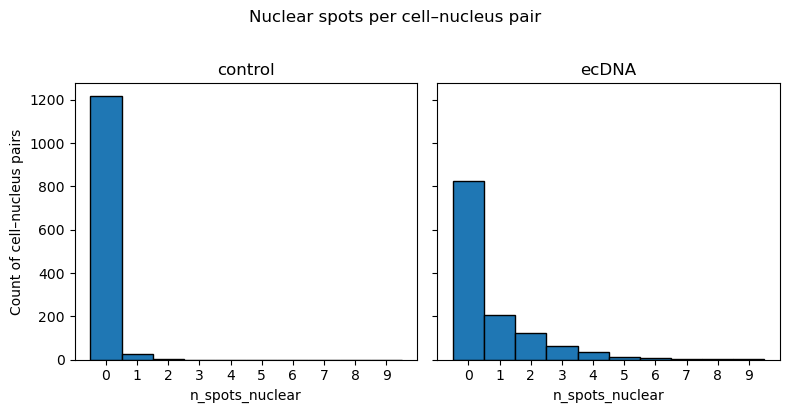

In [31]:
# 1) Plot nuclear spots per cell
plot_int_hist_by_group(spot_pair_summary, "n_spots_nuclear", 
                       group_col="group",
                       title="Nuclear spots per cell–nucleus pair")

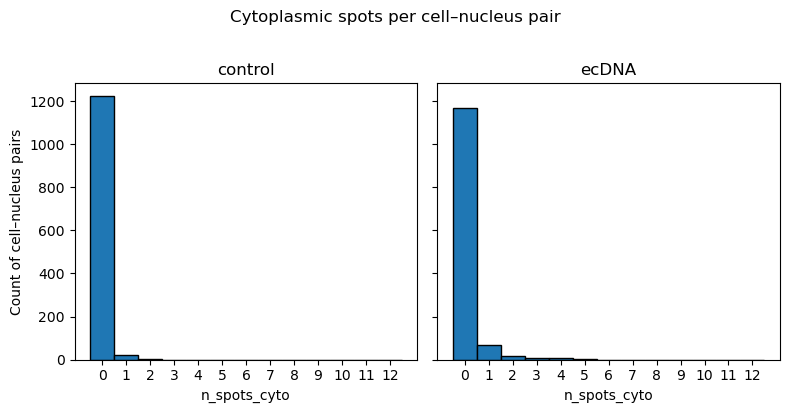

In [32]:
# 2) Plot cytoplasmic spots per cell
plot_int_hist_by_group(spot_pair_summary, "n_spots_cyto", group_col="group",
                       title="Cytoplasmic spots per cell–nucleus pair")

### File saving

The following chunk exports the tables generated to the results folder 

In [104]:
# FILE SAVING #

# Save the tables generated to the results folder in the analysis repository

# Files for each experiment will be saved in their own folder as .csv files
# This approach makes it easy to import them into other notebooks and combine them again if needed

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Get today's date string to use as a suffix if older versions of the file are present
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    # and create it if not already present
    experiment_folder = os.path.join(results_dir, experiment)
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the Data Frame for the current experiment 
    nuclei_counts_e = nuclei_counts[nuclei_counts['experiment'] == experiment]
    all_spots_annot_e = all_spots_annot[all_spots_annot['experiment'] == experiment]
    spot_pair_summary_e = spot_pair_summary[spot_pair_summary['experiment'] == experiment]
    
    # Define the default file path for the CSV file
    nuc_counts_file = os.path.join(experiment_folder, "nuclei_counts.csv")
    spots_annot_file = os.path.join(experiment_folder, "spots_annotated.csv")
    spots_counts_file = os.path.join(experiment_folder, "spots_counts.csv")
    
    # If the raw (no BS) file already exists, add the date suffix to create a new filename
    if os.path.exists(nuc_counts_file):
        nuc_counts_file = os.path.join(experiment_folder, f"nuclei_counts_{date_suffix}.csv")
        spots_annot_file = os.path.join(experiment_folder, f"spots_annotated_{date_suffix}.csv")
        spots_counts_file = os.path.join(experiment_folder, f"spots_counts_{date_suffix}.csv")
    
    # Save the data frame to its CSV file
    nuclei_counts_e.to_csv(nuc_counts_file, index=False)
    all_spots_annot_e.to_csv(spots_annot_file, index=False)
    spot_pair_summary_e.to_csv(spots_counts_file, index=False)